In [ ]:
pip install numpy==1.26.4 gymnasium==1.2.3 minari==0.5.3

In [ ]:
# -*- coding: utf-8 -*-
"""NewG2ANET.ipynb

Automatically generated by Colab.

Original file is located at
    https://colab.research.google.com/drive/1yyzhuhQjUZNVGyXNceYte8RDX8lImvUQ

Cell 1 — Mount Drive and install packages
"""

# !pip uninstall -y gymnasium
# !pip install gymnasium==1.2.3
# !pip uninstall -y minari
# !pip install minari==0.5.3
# !pip uninstall -y numpy minari gymnasium
# !pip install numpy==1.26.4
# !pip install gymnasium==1.2.3 minari==0.5.3

from google.colab import drive
drive.mount('/content/drive')

import numpy as np
import gymnasium
import minari

print("numpy:", np.__version__)
print("gymnasium:", gymnasium.__version__)
print("minari ok")

# import sys

# !{sys.executable} -m pip uninstall -y numpy minari gymnasium
# !{sys.executable} -m pip install --no-cache-dir numpy==1.26.4
# !{sys.executable} -m pip install --no-cache-dir minari==0.5.2 gymnasium==0.28.1

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
numpy: 1.26.4
gymnasium: 1.2.3
minari ok


In [ ]:
import os
import re
import copy
import json
import math
import random
from pathlib import Path
from tqdm import tqdm
import time
import minari
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F

from torch.utils.data import Dataset, DataLoader

# ---- YOUR DRIVE PATH ----
DATA_ROOT = Path("/content/drive/MyDrive/Winter 2026/EECS 295P/Data/eecs_295p_gnn_research_report")
DATA_ROOT.mkdir(parents=True, exist_ok=True)

# Tell Minari to read datasets from your Drive folder
os.environ["MINARI_DATASETS_PATH"] = str(DATA_ROOT)

print("MINARI_DATASETS_PATH =", os.environ["MINARI_DATASETS_PATH"])
print("Exists:", DATA_ROOT.exists())

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", DEVICE)

MINARI_DATASETS_PATH = /content/drive/MyDrive/Winter 2026/EECS 295P/Data/eecs_295p_gnn_research_report
Exists: True
Using device: cuda


In [ ]:
def get_dataset_plan():
    """
    Only use the 3 size folders the user showed:
      uci/small/
      uci/medium/
      uci/large/

    Inside each size folder, auto-discover every Minari shard folder like:
      battle_v4-small_part000-v5
      battle_v4-medium_part003-v5
      battle_v4-large_part012-v5
    """
    return [
        {"name": "small",  "size": "small"},
        {"name": "medium", "size": "medium"},
        {"name": "large",  "size": "large"},
    ]


def resolve_dataset_ids(spec):
    """
    Build dataset ids by scanning Drive folders directly.

    Expected Drive layout:
      DATA_ROOT/uci/small/battle_v4-small_part000-v5/data
      DATA_ROOT/uci/medium/battle_v4-medium_part000-v5/data
      DATA_ROOT/uci/large/battle_v4-large_part000-v5/data

    Returned Minari ids look like:
      uci/small/battle_v4-small_part000-v5
    """
    size = spec["size"]
    size_dir = DATA_ROOT / "uci" / size

    if not size_dir.exists():
        raise FileNotFoundError(f"Size folder not found: {size_dir}")

    shard_dirs = []
    for child in sorted(size_dir.iterdir()):
        if not child.is_dir():
            continue
        if not child.name.startswith(f"battle_v4-{size}_part"):
            continue
        if not (child / "data").exists():
            print(f"[WARN] skipping folder without data/: {child}")
            continue
        shard_dirs.append(child)

    if not shard_dirs:
        raise FileNotFoundError(
            f"No valid shards found under {size_dir}. Expected folders like battle_v4-{size}_part000-v5/data"
        )

    dataset_ids = [f"uci/{size}/{d.name}" for d in shard_dirs]
    return dataset_ids


dataset_plan = get_dataset_plan()
for spec in dataset_plan:
    resolved = resolve_dataset_ids(spec)
    print(spec["name"], "->", resolved[:3], "..." if len(resolved) > 3 else "")

small -> ['uci/small/battle_v4-small_part000-v5', 'uci/small/battle_v4-small_part001-v5'] 
medium -> ['uci/medium/battle_v4-medium_part000-v5', 'uci/medium/battle_v4-medium_part001-v5', 'uci/medium/battle_v4-medium_part002-v5'] ...
large -> ['uci/large/battle_v4-large_part000-v5', 'uci/large/battle_v4-large_part001-v5', 'uci/large/battle_v4-large_part002-v5'] ...


In [ ]:
def infer_dataset_dims(dataset_id):
    """
    Read one episode from one shard and infer:
      - node feature dimension
      - number of agents
      - action space size (estimated from actions in that shard)
    """
    print(f"[INFO] Inferring dims from: {dataset_id}")
    ds = minari.load_dataset(dataset_id)

    first_ep = None
    max_action = -1

    for ep in ds.iterate_episodes():
        if first_ep is None:
            first_ep = ep
        ep_max = int(np.max(ep.actions))
        if ep_max > max_action:
            max_action = ep_max

    if first_ep is None:
        raise ValueError(f"No episodes found in dataset: {dataset_id}")

    obs = first_ep.observations
    node_feat_dim = int(obs["node_feat"].shape[-1])
    num_agents = int(obs["node_feat"].shape[-2])
    num_actions = int(max_action + 1)

    info = {
        "node_feat_dim": node_feat_dim,
        "num_agents": num_agents,
        "num_actions": num_actions,
    }

    print("[INFO] Inferred dims:", info)
    return info

In [ ]:
class MinariDGNTransitionDataset(Dataset):
    """
    Loads one or more Minari dataset shards and exposes step transitions:
        s_t, a_t, r_t, done_t, s_{t+1}

    Expected observation keys:
        - node_feat   : (T+1, N, F)
        - agent_mask  : (T+1, N)
        - edge_index  : (T+1, 2, E_max)
        - edge_valid  : (T+1, E_max)

    Expected step arrays:
        - actions      : (T, N)
        - rewards      : (T, N)
        - terminations : (T,)
        - truncations  : (T,)
    """

    def __init__(self, dataset_ids, keep_padded_edges=True, device=None):
        if isinstance(dataset_ids, str):
            dataset_ids = [dataset_ids]

        self.dataset_ids = dataset_ids
        self.keep_padded_edges = keep_padded_edges
        self.device = device

        self.episodes = []
        self.index_map = []   # list of (episode_idx, t)

        for ds_id in dataset_ids:
            print(f"Loading Minari dataset: {ds_id}")
            ds = minari.load_dataset(ds_id)

            for ep in ds.iterate_episodes():
                obs = ep.observations
                T = ep.actions.shape[0]

                assert obs["node_feat"].shape[0] == T + 1, f"{ds_id}: node_feat not T+1"
                assert obs["agent_mask"].shape[0] == T + 1, f"{ds_id}: agent_mask not T+1"
                assert obs["edge_index"].shape[0] == T + 1, f"{ds_id}: edge_index not T+1"
                assert obs["edge_valid"].shape[0] == T + 1, f"{ds_id}: edge_valid not T+1"

                ep_idx = len(self.episodes)
                self.episodes.append(ep)

                for t in range(T):
                    self.index_map.append((ep_idx, t))

        if len(self.index_map) == 0:
            raise ValueError("No transitions found in provided Minari datasets.")

        print(f"Total transitions loaded: {len(self.index_map)}")

    def __len__(self):
        return len(self.index_map)

    def _to_tensor(self, x, dtype=None):
        t = torch.as_tensor(x, dtype=dtype) if dtype is not None else torch.as_tensor(x)
        if self.device is not None:
            t = t.to(self.device)
        return t

    def _extract_edges(self, edge_index, edge_valid):
        valid = edge_valid.astype(bool)
        return edge_index[:, valid]

    def __getitem__(self, idx):
        ep_idx, t = self.index_map[idx]
        ep = self.episodes[ep_idx]
        obs = ep.observations

        node_feat = obs["node_feat"][t]
        agent_mask = obs["agent_mask"][t]
        edge_index = obs["edge_index"][t]
        edge_valid = obs["edge_valid"][t]

        next_node_feat = obs["node_feat"][t + 1]
        next_agent_mask = obs["agent_mask"][t + 1]
        next_edge_index = obs["edge_index"][t + 1]
        next_edge_valid = obs["edge_valid"][t + 1]

        actions = ep.actions[t]
        rewards = ep.rewards[t]
        done = np.uint8(ep.terminations[t] or ep.truncations[t])

        sample = {
            "node_feat": self._to_tensor(node_feat, torch.float32),
            "agent_mask": self._to_tensor(agent_mask, torch.float32),
            "actions": self._to_tensor(actions, torch.int64),
            "rewards": self._to_tensor(rewards, torch.float32),
            "done": self._to_tensor(done, torch.float32),
            "next_node_feat": self._to_tensor(next_node_feat, torch.float32),
            "next_agent_mask": self._to_tensor(next_agent_mask, torch.float32),
        }

        if self.keep_padded_edges:
            sample["edge_index"] = self._to_tensor(edge_index, torch.int64)
            sample["edge_valid"] = self._to_tensor(edge_valid, torch.float32)
            sample["next_edge_index"] = self._to_tensor(next_edge_index, torch.int64)
            sample["next_edge_valid"] = self._to_tensor(next_edge_valid, torch.float32)
        else:
            active_ei = self._extract_edges(edge_index, edge_valid)
            next_active_ei = self._extract_edges(next_edge_index, next_edge_valid)
            sample["edge_index"] = self._to_tensor(active_ei, torch.int64)
            sample["next_edge_index"] = self._to_tensor(next_active_ei, torch.int64)

        return sample

In [ ]:
class G2ANet(nn.Module):
    def __init__(
        self,
        node_feat_dim,
        hidden_dim,
        num_actions,
        num_heads,
        num_layers,
        dropout=0.0,
    ):
        super().__init__()
        self.input_proj = nn.Linear(node_feat_dim, hidden_dim)
        self.layers = nn.ModuleList(
            [
                G2AAttentionLayer(hidden_dim, num_heads, dropout)
                for _ in range(num_layers)
            ]
        )
        self.output_proj = nn.Linear(hidden_dim, num_actions)

    def forward(self, x, edge_index, edge_valid, agent_mask):
        x = F.relu(self.input_proj(x))
        for layer in self.layers:
            x = layer(x, edge_index, edge_valid, agent_mask)
        return self.output_proj(x)


class G2AAttentionLayer(nn.Module):
    """
    Faster vectorized G2A-style graph attention layer.
    Avoids Python loops over heads/nodes.
    """

    def __init__(self, hidden_dim=64, num_heads=4, dropout=0.0):
        super().__init__()
        assert hidden_dim % num_heads == 0

        self.hidden_dim = hidden_dim
        self.num_heads = num_heads
        self.head_dim = hidden_dim // num_heads
        self.scale = math.sqrt(self.head_dim)

        self.q_proj = nn.Linear(hidden_dim, hidden_dim)
        self.k_proj = nn.Linear(hidden_dim, hidden_dim)
        self.v_proj = nn.Linear(hidden_dim, hidden_dim)

        self.gate_mlp = nn.Sequential(
            nn.Linear(hidden_dim * 2, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, num_heads),
            nn.Sigmoid(),
        )

        self.out_proj = nn.Linear(hidden_dim, hidden_dim)
        self.dropout = nn.Dropout(dropout)
        self.norm = nn.LayerNorm(hidden_dim)

    def forward(self, x, edge_index, edge_valid, agent_mask):
        """
        x:          (B, N, D)
        edge_index: (B, 2, E)
        edge_valid: (B, E)
        agent_mask: (B, N)
        """
        B, N, D = x.shape
        H = self.num_heads
        Dh = self.head_dim

        residual = x

        q = self.q_proj(x).view(B, N, H, Dh)
        k = self.k_proj(x).view(B, N, H, Dh)
        v = self.v_proj(x).view(B, N, H, Dh)

        # Build dense adjacency mask: adj[b, dst, src] = True
        adj = torch.zeros(B, N, N, device=x.device, dtype=torch.bool)

        for b in range(B):
            valid_edges = edge_valid[b].bool()
            ei = edge_index[b][:, valid_edges]

            if ei.numel() == 0:
                continue

            src = ei[0].long()
            dst = ei[1].long()

            alive = agent_mask[b].bool()
            keep = alive[src] & alive[dst]

            src = src[keep]
            dst = dst[keep]

            if src.numel() == 0:
                continue

            adj[b, dst, src] = True

        # Rearrange for multi-head attention
        qh = q.permute(0, 2, 1, 3)  # (B, H, N, Dh)
        kh = k.permute(0, 2, 1, 3)  # (B, H, N, Dh)
        vh = v.permute(0, 2, 1, 3)  # (B, H, N, Dh)

        # Attention scores: destination i attends over source j
        scores = torch.einsum("bhid,bhjd->bhij", qh, kh) / self.scale  # (B, H, N, N)

        # Edge gates from concatenated (dst, src)
        x_dst = x.unsqueeze(2).expand(B, N, N, D)  # (B, N, N, D)
        x_src = x.unsqueeze(1).expand(B, N, N, D)  # (B, N, N, D)
        pair_feat = torch.cat([x_dst, x_src], dim=-1)  # (B, N, N, 2D)

        gates = self.gate_mlp(pair_feat)              # (B, N, N, H)
        gates = gates.permute(0, 3, 1, 2)            # (B, H, N, N)

        scores = scores * gates

        # Mask invalid edges
        mask = adj.unsqueeze(1)  # (B, 1, N, N)
        has_nbr = mask.any(dim=-1, keepdim=True)  # (B, 1, N, 1)

        scores = scores.masked_fill(~mask, -1e9)
        scores = torch.where(has_nbr, scores, torch.zeros_like(scores))

        attn = torch.softmax(scores, dim=-1)
        attn = attn * mask.float()
        attn = self.dropout(attn)

        # Aggregate messages
        out = torch.einsum("bhij,bhjd->bhid", attn, vh)  # (B, H, N, Dh)
        out = out.permute(0, 2, 1, 3).reshape(B, N, D)  # (B, N, D)

        out = self.out_proj(out)
        out = out * agent_mask.unsqueeze(-1).float()

        return self.norm(residual + out)

In [ ]:
def train_step_g2a(
    model,
    target_model,
    batch,
    optimizer,
    gamma=0.99,
    grad_clip=10.0,
):
    node_feat = batch["node_feat"].float()
    edge_index = batch["edge_index"].long()
    edge_valid = batch["edge_valid"].float()
    agent_mask = batch["agent_mask"].float()

    actions = batch["actions"].long()
    rewards = batch["rewards"].float()
    done = batch["done"].float()

    next_node_feat = batch["next_node_feat"].float()
    next_edge_index = batch["next_edge_index"].long()
    next_edge_valid = batch["next_edge_valid"].float()
    next_agent_mask = batch["next_agent_mask"].float()

    q = model(node_feat, edge_index, edge_valid, agent_mask)  # (B, N, A)
    q_taken = torch.gather(q, dim=2, index=actions.unsqueeze(-1)).squeeze(-1)  # (B, N)

    with torch.no_grad():
        next_q_online = model(
            next_node_feat, next_edge_index, next_edge_valid, next_agent_mask
        )
        next_actions = next_q_online.argmax(dim=2, keepdim=True)

        next_q_target = target_model(
            next_node_feat, next_edge_index, next_edge_valid, next_agent_mask
        )
        next_q_selected = torch.gather(
            next_q_target, dim=2, index=next_actions
        ).squeeze(-1)

        done_expand = done.unsqueeze(-1)  # (B,1)
        target = rewards + gamma * (1.0 - done_expand) * next_q_selected

    loss_per_entry = F.smooth_l1_loss(q_taken, target, reduction="none")
    loss = (loss_per_entry * agent_mask).sum() / agent_mask.sum().clamp(min=1.0)

    optimizer.zero_grad()
    loss.backward()
    torch.nn.utils.clip_grad_norm_(model.parameters(), grad_clip)
    optimizer.step()

    stats = {
        "loss": float(loss.item()),
        "q_mean": float(q_taken.mean().item()),
        "q_max": float(q.max().item()),
        "target_mean": float(target.mean().item()),
        "reward_mean": float(rewards.mean().item()),
        "alive_agents_mean": float(agent_mask.sum(dim=1).mean().item()),
    }
    return stats


def save_training_checkpoint(
    checkpoint_path,
    model,
    target_model,
    optimizer,
    history,
    dataset_ids,
    current_part_idx,
    global_step,
    extra_info=None,
):
    checkpoint = {
        "model_state_dict": model.state_dict(),
        "target_model_state_dict": target_model.state_dict(),
        "optimizer_state_dict": optimizer.state_dict(),
        "history": history,
        "dataset_ids": dataset_ids,
        "current_part_idx": current_part_idx,
        "global_step": global_step,
        "extra_info": extra_info or {},
    }
    torch.save(checkpoint, checkpoint_path)
    print(f"[OK] Saved checkpoint: {checkpoint_path}")


def load_training_checkpoint(checkpoint_path, model, target_model, optimizer, device="cpu"):
    checkpoint = torch.load(checkpoint_path, map_location=device)

    model.load_state_dict(checkpoint["model_state_dict"])
    target_model.load_state_dict(checkpoint["target_model_state_dict"])
    optimizer.load_state_dict(checkpoint["optimizer_state_dict"])

    history = checkpoint.get("history", [])
    dataset_ids = checkpoint.get("dataset_ids", [])
    current_part_idx = checkpoint.get("current_part_idx", 0)
    global_step = checkpoint.get("global_step", 0)
    extra_info = checkpoint.get("extra_info", {})

    print(f"[OK] Loaded checkpoint: {checkpoint_path}")
    print(f"Resume shard index: {current_part_idx}")
    print(f"Resume global step: {global_step}")

    return {
        "history": history,
        "dataset_ids": dataset_ids,
        "current_part_idx": current_part_idx,
        "global_step": global_step,
        "extra_info": extra_info,
    }


def moving_average(values, window=50):
    if len(values) == 0:
        return []
    out = []
    for i in range(len(values)):
        start = max(0, i - window + 1)
        out.append(sum(values[start:i+1]) / (i - start + 1))
    return out


def plot_training_history(history, title="Training History", window=50):
    if len(history) == 0:
        print("[WARN] No history to plot.")
        return

    losses = [h["loss"] for h in history]
    q_means = [h.get("q_mean", 0.0) for h in history]
    target_means = [h.get("target_mean", 0.0) for h in history]
    reward_means = [h.get("reward_mean", 0.0) for h in history]

    plt.figure(figsize=(12, 8))

    plt.subplot(2, 2, 1)
    plt.plot(losses, alpha=0.3, label="raw")
    plt.plot(moving_average(losses, window), label=f"ma{window}")
    plt.title("Loss")
    plt.legend()

    plt.subplot(2, 2, 2)
    plt.plot(q_means, alpha=0.3, label="q_mean")
    plt.plot(moving_average(q_means, window), label=f"ma{window}")
    plt.title("Q Mean")
    plt.legend()

    plt.subplot(2, 2, 3)
    plt.plot(target_means, alpha=0.3, label="target_mean")
    plt.plot(moving_average(target_means, window), label=f"ma{window}")
    plt.title("Target Mean")
    plt.legend()

    plt.subplot(2, 2, 4)
    plt.plot(reward_means, alpha=0.3, label="reward_mean")
    plt.plot(moving_average(reward_means, window), label=f"ma{window}")
    plt.title("Reward Mean")
    plt.legend()

    plt.suptitle(title)
    plt.tight_layout()
    plt.show()

In [ ]:
def train_sequential_shards(
    model,
    train_step_fn,
    dataset_ids,
    device="cpu",
    batch_size=32,
    lr=1e-4,
    weight_decay=1e-5,
    epochs_per_shard=1,
    num_workers=0,
    keep_padded_edges=True,
    shuffle_shards=False,
    target_update_every=200,
    checkpoint_dir="./checkpoints",
    checkpoint_every_shard=True,
    checkpoint_every_steps=None,
    resume_checkpoint_path=None,
    max_steps=None,
    dataloader_shuffle=True,
):
    import time
    os.makedirs(checkpoint_dir, exist_ok=True)

    model = model.to(device)
    target_model = copy.deepcopy(model).to(device)
    target_model.load_state_dict(model.state_dict())
    target_model.eval()

    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)

    history = []
    global_step = 0
    start_part_idx = 0

    if shuffle_shards:
        dataset_ids = list(dataset_ids)
        random.shuffle(dataset_ids)

    if resume_checkpoint_path is not None:
        resume_data = load_training_checkpoint(
            resume_checkpoint_path, model, target_model, optimizer, device=device
        )
        history = resume_data["history"]
        global_step = resume_data["global_step"]
        start_part_idx = resume_data["current_part_idx"]

        ckpt_dataset_ids = resume_data["dataset_ids"]
        if len(ckpt_dataset_ids) > 0:
            dataset_ids = ckpt_dataset_ids

    print("\n===== TRAINING CONFIG =====")
    print("device:", device)
    print("num_shards:", len(dataset_ids))
    print("batch_size:", batch_size)
    print("lr:", lr)
    print("epochs_per_shard:", epochs_per_shard)
    print("target_update_every:", target_update_every)
    print("start_part_idx:", start_part_idx)
    print("global_step:", global_step)
    print("===========================\n")

    overall_start_time = time.time()

    for part_idx in range(start_part_idx, len(dataset_ids)):
        ds_id = dataset_ids[part_idx]
        print(f"\n=== Loading shard {part_idx+1}/{len(dataset_ids)}: {ds_id} ===")

        dataset = MinariDGNTransitionDataset(
            dataset_ids=ds_id,
            keep_padded_edges=keep_padded_edges,
            device=None,
        )

        loader = DataLoader(
            dataset,
            batch_size=batch_size,
            shuffle=dataloader_shuffle,
            num_workers=num_workers,
            pin_memory=False,
            drop_last=False,
        )

        print(f"Transitions in shard: {len(dataset)}")

        for epoch in range(epochs_per_shard):
            print(f"--- Epoch {epoch+1}/{epochs_per_shard} on {ds_id} ---")

            shard_start_time = time.time()
            num_batches = len(loader)

            pbar = tqdm(
                loader,
                total=num_batches,
                desc=f"Shard {part_idx+1}/{len(dataset_ids)}",
                leave=True,
            )

            for batch_idx, batch in enumerate(pbar, start=1):
                batch = {
                    k: v.to(device) if hasattr(v, "to") else v
                    for k, v in batch.items()
                }

                model.train()
                stats = train_step_fn(model, target_model, batch, optimizer)
                history.append(stats)
                global_step += 1

                # timing
                shard_elapsed = time.time() - shard_start_time
                overall_elapsed = time.time() - overall_start_time
                sec_per_step_shard = shard_elapsed / batch_idx if batch_idx > 0 else 0.0
                shard_eta_sec = sec_per_step_shard * (num_batches - batch_idx)

                # update tqdm bar text
                pbar.set_postfix({
                    "loss": f"{stats['loss']:.4f}",
                    "s/it": f"{sec_per_step_shard:.3f}",
                    "ETA_min": f"{shard_eta_sec/60:.1f}",
                })

                if global_step % 20 == 0:
                    print(
                        f"step {global_step:6d} | "
                        f"loss {stats['loss']:.5f} | "
                        f"q_mean {stats.get('q_mean', 0.0):.4f} | "
                        f"target_mean {stats.get('target_mean', 0.0):.4f} | "
                        f"reward_mean {stats.get('reward_mean', 0.0):.4f} | "
                        f"q_max {stats.get('q_max', 0.0):.4f} | "
                        f"alive_agents_mean {stats.get('alive_agents_mean', 0.0):.3f} | "
                        f"{sec_per_step_shard:.3f}s/step | "
                        f"shard_eta {shard_eta_sec/60:.1f} min"
                    )

                if global_step % target_update_every == 0:
                    target_model.load_state_dict(model.state_dict())

                if checkpoint_every_steps is not None and global_step % checkpoint_every_steps == 0:
                    ckpt_path = os.path.join(checkpoint_dir, f"step_{global_step:06d}.pt")
                    save_training_checkpoint(
                        checkpoint_path=ckpt_path,
                        model=model,
                        target_model=target_model,
                        optimizer=optimizer,
                        history=history,
                        dataset_ids=dataset_ids,
                        current_part_idx=part_idx,
                        global_step=global_step,
                        extra_info={"last_dataset_id": ds_id},
                    )

                if max_steps is not None and global_step >= max_steps:
                    print(f"[STOP] Reached max_steps={max_steps}")
                    final_ckpt = os.path.join(checkpoint_dir, "final_checkpoint.pt")
                    save_training_checkpoint(
                        checkpoint_path=final_ckpt,
                        model=model,
                        target_model=target_model,
                        optimizer=optimizer,
                        history=history,
                        dataset_ids=dataset_ids,
                        current_part_idx=part_idx,
                        global_step=global_step,
                        extra_info={"last_dataset_id": ds_id},
                    )
                    return model, target_model, history

            print(
                f"[DONE] shard {part_idx+1}/{len(dataset_ids)} finished in "
                f"{(time.time() - shard_start_time)/60:.2f} min"
            )

        if checkpoint_every_shard:
            ckpt_path = os.path.join(checkpoint_dir, f"after_shard_{part_idx:03d}.pt")
            save_training_checkpoint(
                checkpoint_path=ckpt_path,
                model=model,
                target_model=target_model,
                optimizer=optimizer,
                history=history,
                dataset_ids=dataset_ids,
                current_part_idx=part_idx + 1,
                global_step=global_step,
                extra_info={"last_dataset_id": ds_id},
            )

        del dataset
        del loader
        if device.startswith("cuda") and torch.cuda.is_available():
            torch.cuda.empty_cache()

    final_ckpt = os.path.join(checkpoint_dir, "final_checkpoint.pt")
    save_training_checkpoint(
        checkpoint_path=final_ckpt,
        model=model,
        target_model=target_model,
        optimizer=optimizer,
        history=history,
        dataset_ids=dataset_ids,
        current_part_idx=len(dataset_ids),
        global_step=global_step,
        extra_info={"status": "completed"},
    )

    print(f"\n[ALL DONE] total training time: {(time.time() - overall_start_time)/60:.2f} min")
    return model, target_model, history

In [ ]:
def make_g2anet_model(
    node_feat_dim,
    hidden_dim=64,
    num_actions=21,
    num_heads=4,
    num_layers=2,
    dropout=0.0,
):
    return G2ANet(
        node_feat_dim=node_feat_dim,
        hidden_dim=hidden_dim,
        num_actions=num_actions,
        num_heads=num_heads,
        num_layers=num_layers,
        dropout=dropout,
    )


def get_default_train_args(size):
    """
    You can tune these later.
    I set them to be practical starting points.
    """
    if size == "small":
        return {
            "batch_size": 32,
            "lr": 1e-4,
            "weight_decay": 1e-5,
            "epochs_per_shard": 2,
            "target_update_every": 100,
            "max_steps": 500,
        }
    elif size == "medium":
        return {
            "batch_size": 32,
            "lr": 1e-4,
            "weight_decay": 1e-5,
            "epochs_per_shard": 1,
            "target_update_every": 200,
            "max_steps": 2000,
        }
    else:  # large
        return {
            "batch_size": 32,
            "lr": 1e-4,
            "weight_decay": 1e-5,
            "epochs_per_shard": 1,
            "target_update_every": 200,
            "max_steps": 4000,
        }

def run_one_experiment(spec, root_ckpt_dir=DATA_ROOT / "g2anet_checkpoints"):
    print("\n" + "="*70)
    print(f"Running experiment: {spec['name']}")
    print("="*70)

    dataset_ids = resolve_dataset_ids(spec)
    print("Dataset IDs:")
    for ds in dataset_ids[:5]:
        print("  ", ds)
    if len(dataset_ids) > 5:
        print(f"  ... total {len(dataset_ids)} shards")

    # infer real dims from first shard
    dims = infer_dataset_dims(dataset_ids[0])

    train_args = get_default_train_args(spec["size"])

    model = make_g2anet_model(
        node_feat_dim=dims["node_feat_dim"],
        hidden_dim=64,
        num_actions=dims["num_actions"],
        num_heads=4,
        num_layers=2,
        dropout=0.0,
    )

    checkpoint_dir = root_ckpt_dir / spec["name"]
    checkpoint_dir.mkdir(parents=True, exist_ok=True)

    model, target_model, history = train_sequential_shards(
        model=model,
        train_step_fn=train_step_g2a,
        dataset_ids=dataset_ids,
        device=DEVICE,
        batch_size=train_args["batch_size"],
        lr=train_args["lr"],
        weight_decay=train_args["weight_decay"],
        epochs_per_shard=train_args["epochs_per_shard"],
        num_workers=0,
        keep_padded_edges=True,
        shuffle_shards=False,
        target_update_every=train_args["target_update_every"],
        checkpoint_dir=str(checkpoint_dir),
        checkpoint_every_shard=True,
        checkpoint_every_steps=None,
        resume_checkpoint_path=None,
        max_steps=train_args["max_steps"],
        dataloader_shuffle=True,
    )

    plot_training_history(history, title=f"G2ANet - {spec['name']}", window=50)

    final_stats = history[-1] if len(history) > 0 else {}
    summary = {
        "name": spec["name"],
        "size": spec["size"],
        "num_shards": len(dataset_ids),
        "steps": len(history),
        "node_feat_dim": dims["node_feat_dim"],
        "num_agents": dims["num_agents"],
        "num_actions": dims["num_actions"],
        "final_loss": final_stats.get("loss", None),
        "final_q_mean": final_stats.get("q_mean", None),
        "final_target_mean": final_stats.get("target_mean", None),
        "final_reward_mean": final_stats.get("reward_mean", None),
    }

    summary_path = checkpoint_dir / "summary.json"
    with open(summary_path, "w") as f:
        json.dump(summary, f, indent=2)

    print("\nSaved summary to:", summary_path)
    print(json.dumps(summary, indent=2))

    return {
        "model": model,
        "target_model": target_model,
        "history": history,
        "summary": summary,
    }

In [ ]:
test_spec = dataset_plan[0]   # small
test_ids = resolve_dataset_ids(test_spec)
dims = infer_dataset_dims(test_ids[0])
print(dims)

[INFO] Inferring dims from: uci/small/battle_v4-small_part000-v5
[INFO] Inferred dims: {'node_feat_dim': 12, 'num_agents': 40, 'num_actions': 21}
{'node_feat_dim': 12, 'num_agents': 40, 'num_actions': 21}



Running experiment: small
Dataset IDs:
   uci/small/battle_v4-small_part000-v5
   uci/small/battle_v4-small_part001-v5
[INFO] Inferring dims from: uci/small/battle_v4-small_part000-v5
[INFO] Inferred dims: {'node_feat_dim': 12, 'num_agents': 40, 'num_actions': 21}

===== TRAINING CONFIG =====
device: cuda
num_shards: 2
batch_size: 32
lr: 0.0001
epochs_per_shard: 2
target_update_every: 100
start_part_idx: 0
global_step: 0


=== Loading shard 1/2: uci/small/battle_v4-small_part000-v5 ===
Loading Minari dataset: uci/small/battle_v4-small_part000-v5
Total transitions loaded: 1000
Transitions in shard: 1000
--- Epoch 1/2 on uci/small/battle_v4-small_part000-v5 ---


Shard 1/2:  78%|███████▊  | 25/32 [00:01<00:00, 26.83it/s, loss=0.1988, s/it=0.064, ETA_min=0.0]

step     20 | loss 0.23305 | q_mean 0.3793 | target_mean 0.8055 | reward_mean -0.0750 | q_max 1.6876 | alive_agents_mean 40.000 | 0.077s/step | shard_eta 0.0 min


Shard 1/2: 100%|██████████| 32/32 [00:01<00:00, 17.19it/s, loss=0.1671, s/it=0.058, ETA_min=0.0]


[DONE] shard 1/2 finished in 0.03 min
--- Epoch 2/2 on uci/small/battle_v4-small_part000-v5 ---


...

step    100 | loss 0.08323 | q_mean 0.3850 | target_mean 0.3464 | reward_mean -0.0648 | q_max 1.6849 | alive_agents_mean 40.000 | 0.027s/step | shard_eta 0.0 min


Shard 2/2:  88%|████████▊ | 28/32 [00:00<00:00, 36.50it/s, loss=0.0358, s/it=0.027, ETA_min=0.0]

step    120 | loss 0.05119 | q_mean 0.5590 | target_mean 0.6757 | reward_mean -0.0591 | q_max 1.6885 | alive_agents_mean 40.000 | 0.027s/step | shard_eta 0.0 min


Shard 2/2: 100%|██████████| 32/32 [00:00<00:00, 37.20it/s, loss=0.0310, s/it=0.027, ETA_min=0.0]


[DONE] shard 2/2 finished in 0.01 min
[OK] Saved checkpoint: /content/drive/MyDrive/Winter 2026/EECS 295P/Data/eecs_295p_gnn_research_report/g2anet_checkpoints/small/after_shard_001.pt
[OK] Saved checkpoint: /content/drive/MyDrive/Winter 2026/EECS 295P/Data/eecs_295p_gnn_research_report/g2anet_checkpoints/small/final_checkpoint.pt

[ALL DONE] total training time: 0.13 min


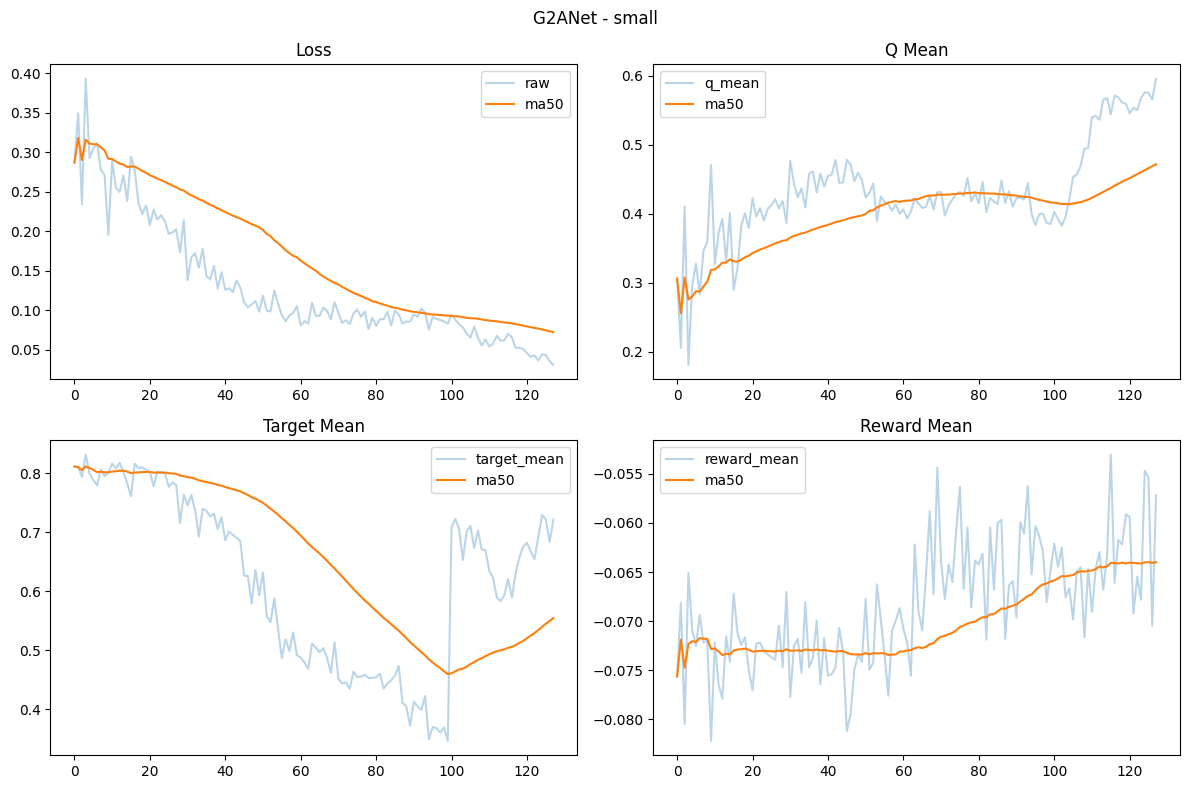


Saved summary to: /content/drive/MyDrive/Winter 2026/EECS 295P/Data/eecs_295p_gnn_research_report/g2anet_checkpoints/small/summary.json
{
  "name": "small",
  "size": "small",
  "num_shards": 2,
  "steps": 128,
  "node_feat_dim": 12,
  "num_agents": 40,
  "num_actions": 21,
  "final_loss": 0.03099273517727852,
  "final_q_mean": 0.5954971313476562,
  "final_target_mean": 0.7213894128799438,
  "final_reward_mean": -0.05718749761581421
}


In [ ]:
# Good first sanity check:
# small, medium, or large

test_spec = dataset_plan[0]   # small
test_result = run_one_experiment(test_spec)

NVIDIA RTX PRO 6000 Blackwell Server Edition
True

Running experiment: small
Dataset IDs:
   uci/small/battle_v4-small_part000-v5
   uci/small/battle_v4-small_part001-v5
[INFO] Inferring dims from: uci/small/battle_v4-small_part000-v5
[INFO] Inferred dims: {'node_feat_dim': 12, 'num_agents': 40, 'num_actions': 21}

===== TRAINING CONFIG =====
device: cuda
num_shards: 2
batch_size: 32
lr: 0.0001
epochs_per_shard: 2
target_update_every: 100
start_part_idx: 0
global_step: 0


=== Loading shard 1/2: uci/small/battle_v4-small_part000-v5 ===
Loading Minari dataset: uci/small/battle_v4-small_part000-v5
Total transitions loaded: 1000
Transitions in shard: 1000
--- Epoch 1/2 on uci/small/battle_v4-small_part000-v5 ---


Shard 1/2:  75%|███████▌  | 24/32 [00:00<00:00, 36.52it/s, loss=0.1912, s/it=0.027, ETA_min=0.0]

step     20 | loss 0.24939 | q_mean 0.5151 | target_mean 0.9283 | reward_mean -0.0713 | q_max 1.4850 | alive_agents_mean 40.000 | 0.028s/step | shard_eta 0.0 min


Shard 1/2: 100%|██████████| 32/32 [00:00<00:00, 37.07it/s, loss=0.0971, s/it=0.027, ETA_min=0.0]


[DONE] shard 1/2 finished in 0.01 min
--- Epoch 2/2 on uci/small/battle_v4-small_part000-v5 ---


...

step    100 | loss 0.08582 | q_mean 0.2422 | target_mean 0.1734 | reward_mean -0.0663 | q_max 1.3682 | alive_agents_mean 40.000 | 0.028s/step | shard_eta 0.0 min


Shard 2/2:  88%|████████▊ | 28/32 [00:00<00:00, 36.12it/s, loss=0.0551, s/it=0.028, ETA_min=0.0]

step    120 | loss 0.06158 | q_mean 0.4825 | target_mean 0.5313 | reward_mean -0.0695 | q_max 1.3942 | alive_agents_mean 40.000 | 0.028s/step | shard_eta 0.0 min


Shard 2/2: 100%|██████████| 32/32 [00:00<00:00, 36.78it/s, loss=0.0361, s/it=0.027, ETA_min=0.0]


[DONE] shard 2/2 finished in 0.01 min
[OK] Saved checkpoint: /content/drive/MyDrive/Winter 2026/EECS 295P/Data/eecs_295p_gnn_research_report/g2anet_checkpoints/small/after_shard_001.pt
[OK] Saved checkpoint: /content/drive/MyDrive/Winter 2026/EECS 295P/Data/eecs_295p_gnn_research_report/g2anet_checkpoints/small/final_checkpoint.pt

[ALL DONE] total training time: 0.06 min


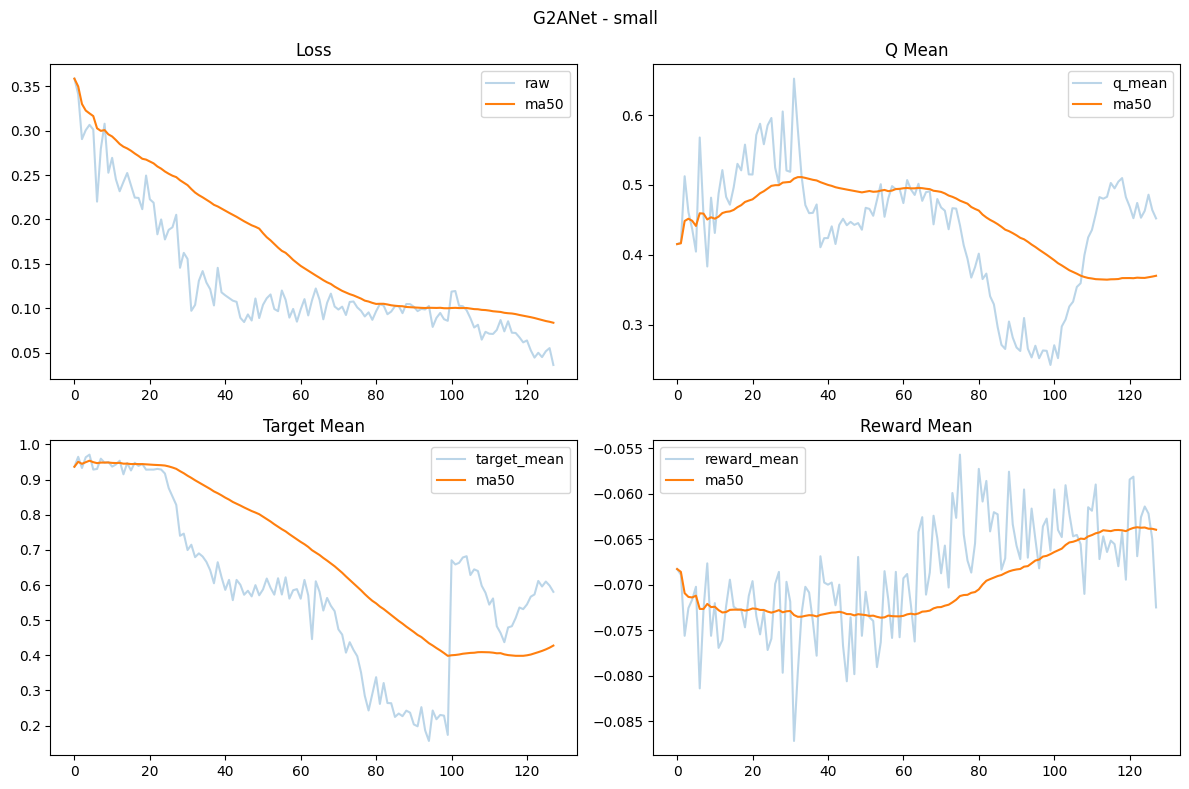


Saved summary to: /content/drive/MyDrive/Winter 2026/EECS 295P/Data/eecs_295p_gnn_research_report/g2anet_checkpoints/small/summary.json
{
  "name": "small",
  "size": "small",
  "num_shards": 2,
  "steps": 128,
  "node_feat_dim": 12,
  "num_agents": 40,
  "num_actions": 21,
  "final_loss": 0.03614765405654907,
  "final_q_mean": 0.452091783285141,
  "final_target_mean": 0.5806052088737488,
  "final_reward_mean": -0.07250000536441803
}

Running experiment: medium
Dataset IDs:
   uci/medium/battle_v4-medium_part000-v5
   uci/medium/battle_v4-medium_part001-v5
   uci/medium/battle_v4-medium_part002-v5
   uci/medium/battle_v4-medium_part003-v5
   uci/medium/battle_v4-medium_part004-v5
  ... total 8 shards
[INFO] Inferring dims from: uci/medium/battle_v4-medium_part000-v5
[INFO] Inferred dims: {'node_feat_dim': 12, 'num_agents': 162, 'num_actions': 21}

===== TRAINING CONFIG =====
device: cuda
num_shards: 8
batch_size: 32
lr: 0.0001
epochs_per_shard: 1
target_update_every: 200
start_part_id

Shard 1/8:  10%|▉         | 23/235 [00:01<00:09, 23.53it/s, loss=0.5089, s/it=0.043, ETA_min=0.2]

step     20 | loss 0.58895 | q_mean -0.1089 | target_mean 0.9045 | reward_mean -0.0659 | q_max 2.0162 | alive_agents_mean 160.281 | 0.043s/step | shard_eta 0.2 min


Shard 1/8:  19%|█▊        | 44/235 [00:01<00:08, 23.68it/s, loss=0.1976, s/it=0.043, ETA_min=0.1]

step     40 | loss 0.22914 | q_mean 0.2694 | target_mean 0.7269 | reward_mean -0.0630 | q_max 2.0324 | alive_agents_mean 159.906 | 0.043s/step | shard_eta 0.1 min


...

step   1840 | loss 0.00314 | q_mean 1.0003 | target_mean 1.0163 | reward_mean -0.0612 | q_max 2.0504 | alive_agents_mean 160.594 | 0.042s/step | shard_eta 0.0 min


Shard 8/8:  93%|█████████▎| 219/235 [00:09<00:00, 24.01it/s, loss=0.0033, s/it=0.042, ETA_min=0.0]

step   1860 | loss 0.00286 | q_mean 0.9791 | target_mean 0.9919 | reward_mean -0.0640 | q_max 2.0488 | alive_agents_mean 160.719 | 0.042s/step | shard_eta 0.0 min


Shard 8/8: 100%|██████████| 235/235 [00:09<00:00, 24.01it/s, loss=0.0554, s/it=0.042, ETA_min=0.0]


step   1880 | loss 0.05544 | q_mean 0.9989 | target_mean 0.9163 | reward_mean -0.0641 | q_max 2.0483 | alive_agents_mean 160.583 | 0.042s/step | shard_eta 0.0 min
[DONE] shard 8/8 finished in 0.16 min
[OK] Saved checkpoint: /content/drive/MyDrive/Winter 2026/EECS 295P/Data/eecs_295p_gnn_research_report/g2anet_checkpoints/medium/after_shard_007.pt
[OK] Saved checkpoint: /content/drive/MyDrive/Winter 2026/EECS 295P/Data/eecs_295p_gnn_research_report/g2anet_checkpoints/medium/final_checkpoint.pt

[ALL DONE] total training time: 1.82 min


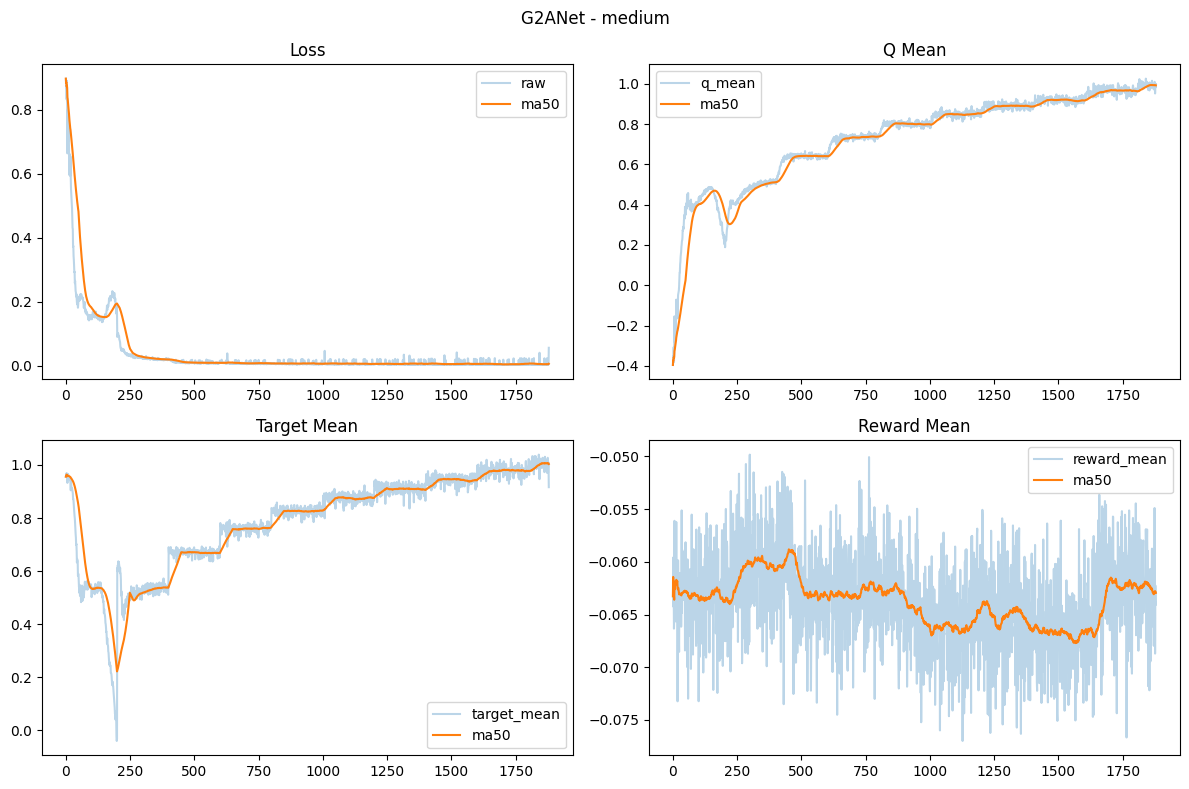


Saved summary to: /content/drive/MyDrive/Winter 2026/EECS 295P/Data/eecs_295p_gnn_research_report/g2anet_checkpoints/medium/summary.json
{
  "name": "medium",
  "size": "medium",
  "num_shards": 8,
  "steps": 1880,
  "node_feat_dim": 12,
  "num_agents": 162,
  "num_actions": 21,
  "final_loss": 0.05544286593794823,
  "final_q_mean": 0.9988766312599182,
  "final_target_mean": 0.916252613067627,
  "final_reward_mean": -0.06406121701002121
}

Running experiment: large
Dataset IDs:
   uci/large/battle_v4-large_part000-v5
   uci/large/battle_v4-large_part001-v5
   uci/large/battle_v4-large_part002-v5
   uci/large/battle_v4-large_part003-v5
   uci/large/battle_v4-large_part004-v5
  ... total 20 shards
[INFO] Inferring dims from: uci/large/battle_v4-large_part000-v5
[INFO] Inferred dims: {'node_feat_dim': 12, 'num_agents': 162, 'num_actions': 21}

===== TRAINING CONFIG =====
device: cuda
num_shards: 20
batch_size: 32
lr: 0.0001
epochs_per_shard: 1
target_update_every: 200
start_part_idx: 0
g

Shard 1/20:   6%|▌         | 24/391 [00:01<00:15, 23.71it/s, loss=0.2420, s/it=0.042, ETA_min=0.3]

step     20 | loss 0.29761 | q_mean 0.2483 | target_mean 0.9210 | reward_mean -0.0591 | q_max 1.7277 | alive_agents_mean 158.406 | 0.042s/step | shard_eta 0.3 min


Shard 1/20:  11%|█         | 42/391 [00:01<00:14, 23.77it/s, loss=0.1634, s/it=0.042, ETA_min=0.2]

step     40 | loss 0.17646 | q_mean 0.5114 | target_mean 0.8334 | reward_mean -0.0642 | q_max 1.7820 | alive_agents_mean 157.031 | 0.042s/step | shard_eta 0.2 min


...

step   3960 | loss 0.00381 | q_mean 0.9022 | target_mean 0.9379 | reward_mean -0.0595 | q_max 1.3219 | alive_agents_mean 157.781 | 0.042s/step | shard_eta 0.2 min


Shard 11/20:  18%|█▊        | 72/391 [00:03<00:13, 23.71it/s, loss=0.0010, s/it=0.042, ETA_min=0.2]

step   3980 | loss 0.00295 | q_mean 0.8938 | target_mean 0.9338 | reward_mean -0.0563 | q_max 1.3139 | alive_agents_mean 157.062 | 0.042s/step | shard_eta 0.2 min


Shard 11/20:  23%|██▎       | 89/391 [00:03<00:12, 23.40it/s, loss=0.0020, s/it=0.042, ETA_min=0.2]


step   4000 | loss 0.00200 | q_mean 0.8971 | target_mean 0.9277 | reward_mean -0.0589 | q_max 1.3117 | alive_agents_mean 158.125 | 0.042s/step | shard_eta 0.2 min
[STOP] Reached max_steps=4000
[OK] Saved checkpoint: /content/drive/MyDrive/Winter 2026/EECS 295P/Data/eecs_295p_gnn_research_report/g2anet_checkpoints/large/final_checkpoint.pt


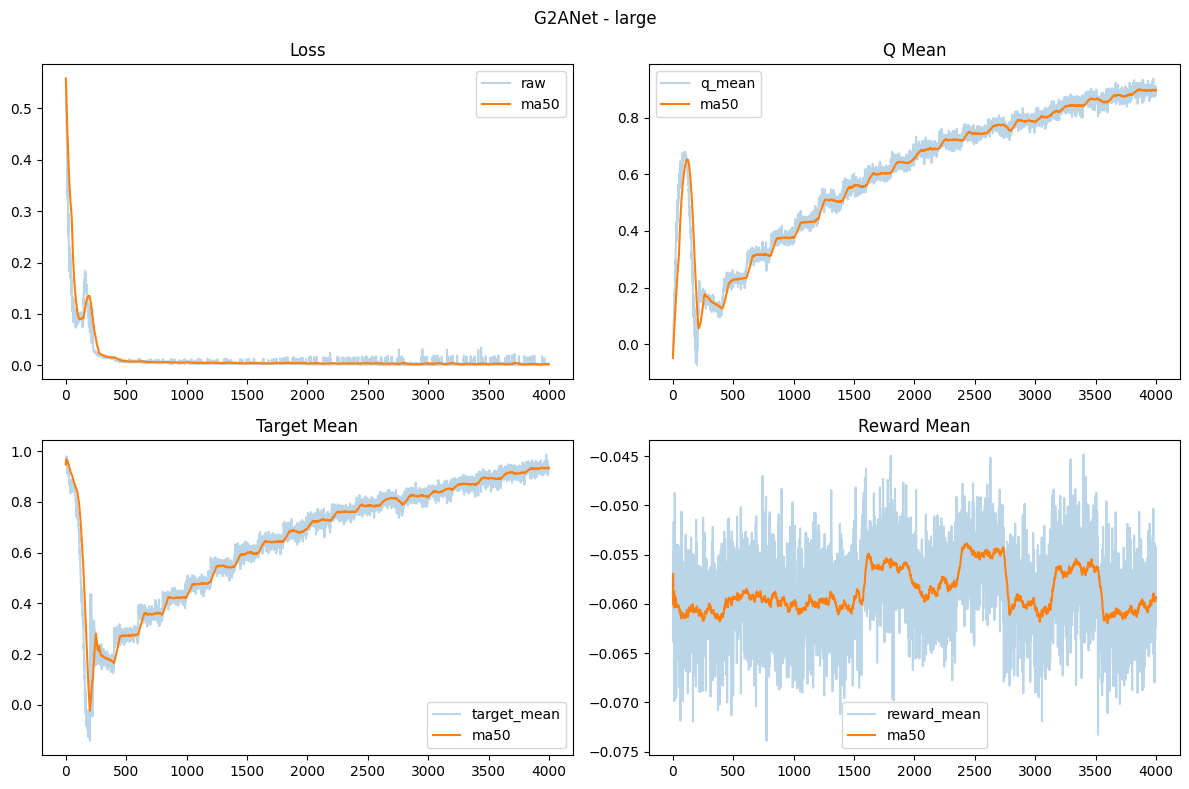


Saved summary to: /content/drive/MyDrive/Winter 2026/EECS 295P/Data/eecs_295p_gnn_research_report/g2anet_checkpoints/large/summary.json
{
  "name": "large",
  "size": "large",
  "num_shards": 20,
  "steps": 4000,
  "node_feat_dim": 12,
  "num_agents": 162,
  "num_actions": 21,
  "final_loss": 0.0019971427973359823,
  "final_q_mean": 0.8971419334411621,
  "final_target_mean": 0.9277181029319763,
  "final_reward_mean": -0.05887249484658241
}


In [ ]:
import torch
print(torch.cuda.get_device_name(0))
print(torch.cuda.is_available())

all_results = {}
all_summaries = []

for spec in dataset_plan:
    try:
        result = run_one_experiment(spec)
        all_results[spec["name"]] = result
        all_summaries.append(result["summary"])
    except Exception as e:
        print(f"\n[ERROR] Failed on {spec['name']}: {e}")
        all_summaries.append({
            "name": spec["name"],
                        "size": spec["size"],
            "error": str(e),
        })

# medium_specs = [spec for spec in dataset_plan if spec["size"] == "medium"]

# medium_results = {}
# medium_summaries = []

# for spec in medium_specs:
#     try:
#         result = run_one_experiment(spec)
#         medium_results[spec["name"]] = result
#         medium_summaries.append(result["summary"])
#     except Exception as e:
#         print(f"\n[ERROR] Failed on {spec['name']}: {e}")
#         medium_summaries.append({
#             "name": spec["name"],
#             #             "size": spec["size"],
#             "error": str(e),
#         })

# large_specs = [spec for spec in dataset_plan if spec["size"] == "large"]

# large_results = {}
# large_summaries = []

# for spec in large_specs:
#     try:
#         result = run_one_experiment(spec)
#         large_results[spec["name"]] = result
#         large_summaries.append(result["summary"])
#     except Exception as e:
#         print(f"\n[ERROR] Failed on {spec['name']}: {e}")
#         large_summaries.append({
#             "name": spec["name"],
#             #             "size": spec["size"],
#             "error": str(e),
#         })

In [ ]:
for s in all_summaries:
    print("-"*80)
    print(json.dumps(s, indent=2))

--------------------------------------------------------------------------------
{
  "name": "small",
  "size": "small",
  "num_shards": 2,
  "steps": 128,
  "node_feat_dim": 12,
  "num_agents": 40,
  "num_actions": 21,
  "final_loss": 0.03614765405654907,
  "final_q_mean": 0.452091783285141,
  "final_target_mean": 0.5806052088737488,
  "final_reward_mean": -0.07250000536441803
}
--------------------------------------------------------------------------------
{
  "name": "medium",
  "size": "medium",
  "num_shards": 8,
  "steps": 1880,
  "node_feat_dim": 12,
  "num_agents": 162,
  "num_actions": 21,
  "final_loss": 0.05544286593794823,
  "final_q_mean": 0.9988766312599182,
  "final_target_mean": 0.916252613067627,
  "final_reward_mean": -0.06406121701002121
}
--------------------------------------------------------------------------------
{
  "name": "large",
  "size": "large",
  "num_shards": 20,
  "steps": 4000,
  "node_feat_dim": 12,
  "num_agents": 162,
  "num_actions": 21,
  "fina

In [ ]:
combined_summary_path = DATA_ROOT / "g2anet_all_runs_summary.json"

with open(combined_summary_path, "w") as f:
    json.dump(all_summaries, f, indent=2)

print("Saved combined summary to:", combined_summary_path)

Saved combined summary to: /content/drive/MyDrive/Winter 2026/EECS 295P/Data/eecs_295p_gnn_research_report/g2anet_all_runs_summary.json


In [ ]:
import pandas as pd
from pathlib import Path

# convert to DataFrame
summary_df = pd.DataFrame(all_summaries)

# display in notebook
display(summary_df)

# save to CSV
csv_path = DATA_ROOT / "g2anet_checkpoints" / "g2anet_summary.csv"
summary_df.to_csv(csv_path, index=False)

print("Saved CSV to:", csv_path)

,name,size,num_shards,steps,node_feat_dim,num_agents,num_actions,final_loss,final_q_mean,final_target_mean,final_reward_mean
0,small,small,2,128,12,40,21,0.036148,0.452092,0.580605,-0.072500
1,medium,medium,8,1880,12,162,21,0.055443,0.998877,0.916253,-0.064061
2,large,large,20,4000,12,162,21,0.001997,0.897142,0.927718,-0.058872


Saved CSV to: /content/drive/MyDrive/Winter 2026/EECS 295P/Data/eecs_295p_gnn_research_report/g2anet_checkpoints/g2anet_summary.csv
